In [2]:
import pandas as pd
from tqdm import tqdm
import os
from datetime import datetime

## 1. 데이터 통합

### 블로그_브런치 데이터 통합

In [ ]:
df0 = pd.read_csv('./crawled/01_VOC/Brunch/블로그_브런치_육아_종합본(2815건).csv', encoding='utf-8-sig')

df0['키워드'] = '육아 ' + df0['키워드']
df0 = df0[['출처', '키워드', '제목', '내용', '작성일', '링크']]

df0.head()

,출처,키워드,제목,내용,작성일,링크
0,블로그_브런치,육아 힘들,"임신, 출산, 육아가 힘들 땐?","책 소개\n19개월 첫째를 돌보고, 이제 두 달 뒤면 둘째 출산을 한다. 크지 않은...",2025-08-05,https://brunch.co.kr/@@bVWd/75
1,블로그_브런치,육아 힘들,"길고 긴 겨울방학 조부모 육아, 이렇게 해보세요","생활계획표 만들고, 손주들과 식단 짜고, 이웃 도서관에서 책 읽고...\n1월 10...",2026-01-20,https://brunch.co.kr/@@ecZ8/974
2,블로그_브런치,육아 힘들,05화 육아가 남기는 삶의 작은 이로움,라이트 에세이 Chapter.5\n육아를 하다 보면 아무리 나를 비틀어짜도 사랑이라...,2025-12-30,https://brunch.co.kr/@@6VCb/275
3,블로그_브런치,육아 힘들,28화 아빠는 육아왕,친정 아빠의 재발견\n우리 아빠는 육아 왕이다.\n나는 이 문장처럼 어색한 문장을 ...,2025-10-14,https://brunch.co.kr/@@70sT/81
4,블로그_브런치,육아 힘들,"06화 연년생 독박 육아, 나를 살린 생존 습관",연년생 독박 육아는 매일이 전시 상황이다. 큰애 기저귀를 갈고 돌아서면 둘째가 울고...,2026-02-10,https://brunch.co.kr/@@4tz2/29


In [ ]:
df1 = pd.read_csv('./crawled/01_VOC/Brunch/블로그_브런치_임신_종합본(2412건).csv', encoding='utf-8-sig')

df1['키워드'] = '임신 ' + df1['키워드']
df1 = df1[['출처', '키워드', '제목', '내용', '작성일', '링크']]

df1.head()

,출처,키워드,제목,내용,작성일,링크
0,블로그_브런치,임신 걱정,"03화 임신 3주차, 기쁨과 걱정 사이에서","이상하게 엄청 졸리고 춥던 주말이었다. 토요일도, 일요일도, 하루에 15시간 정도를...",2026-02-26,https://brunch.co.kr/@@8Mr3/294
1,블로그_브런치,임신 걱정,아무 걱정 없을 것 같았던 임신준비,다낭성난소증후군 + 1%의 정상정자\n우리는 아무 문제가 없을 줄 알았다.\n결혼하...,2026-01-20,https://brunch.co.kr/@@hbtr/20
2,블로그_브런치,임신 걱정,걱정의 나날이 계속된 임신,첫 번째 고비\n임신 소식을 알게 된 이후에 계속 걱정이 되었다.\n우선 병원에서도...,2025-03-26,https://brunch.co.kr/@@50Dl/11
3,블로그_브런치,임신 걱정,01화 임신이라는 세계,얼떨결에 엄마가 되었습니다\n임신 사실을 알게 된 건 8월 초 무렵이었다. 주말 내...,2025-09-26,https://brunch.co.kr/@@2hTm/76
4,블로그_브런치,임신 걱정,21화 임신 30주 입성,절대 만날 수 없을 것 같았던 앞자리 3이라는 숫자\n어제부로 임신 30주차에 접어...,2025-07-16,https://brunch.co.kr/@@3nf/173


In [ ]:
df2 = pd.read_csv('./crawled/01_VOC/Brunch/블로그_브런치_출산_종합본(2775건).csv', encoding='utf-8-sig')

df2['키워드'] = '출산 ' + df2['키워드']
df2 = df2[['출처', '키워드', '제목', '내용', '작성일', '링크']]

df2.head()

,출처,키워드,제목,내용,작성일,링크
0,블로그_브런치,출산 걱정,축하와 축복이 아닌 걱정과 안타까움으로 가득 찬 출산,행복 후에는 늘 불행이 오는걸까? 불행 후에 행복이 오는걸까?\n출산한 지 일주일이...,2025-05-16,https://brunch.co.kr/@@ecSc/2
1,블로그_브런치,출산 걱정,25화 35주 - 출산의 공포를 이겨내는 법,"은 없습니다만\n벌써 35주 차에 접어들었다. 예정일까지 남은 기간은 단 5주, 출...",2025-12-28,https://brunch.co.kr/@@gHAJ/115
2,블로그_브런치,출산 걱정,첫 출산에 대한 걱정 덜어드려요,분만 징후 3가지 & 출산까지 과정\n힐팁은 건강‧생활‧안전 분야의 뉴스와 정보를 ...,2024-07-30,https://brunch.co.kr/@@3tfz/2474
3,블로그_브런치,출산 걱정,"01화 서른셋, 셋째를 출산하다","세 아이의 엄마가 된 91년생이 왔다\n긴 연휴가 시작되기 전인 1월 27일 새벽,...",2025-02-04,https://brunch.co.kr/@@fvha/166
4,블로그_브런치,출산 걱정,28화 임신 중 이것이 걱정돼요 - 출산 통증 관리 마취 방법,다양한 요소를 고려한 맞춤형 접근이 필요\n출산은 여성의 삶에서 가장 강렬한 경험 ...,2025-04-13,https://brunch.co.kr/@@aJvN/35


In [41]:
# 통합

total_brunch_df = pd.concat([df0, df1, df2], ignore_index=True)

# 2. 결과 확인
print(f"통합 전 개수: df0({len(df0)}건), df1({len(df1)}건), df2({len(df2)}건)")
print(f"통합 후 총 개수: {len(total_brunch_df)}건")
total_brunch_df.head()

통합 전 개수: df0(2815건), df1(2412건), df2(2775건)
통합 후 총 개수: 8002건


,출처,키워드,제목,내용,작성일,링크
0,블로그_브런치,육아 힘들,"임신, 출산, 육아가 힘들 땐?","책 소개\n19개월 첫째를 돌보고, 이제 두 달 뒤면 둘째 출산을 한다. 크지 않은...",2025-08-05,https://brunch.co.kr/@@bVWd/75
1,블로그_브런치,육아 힘들,"길고 긴 겨울방학 조부모 육아, 이렇게 해보세요","생활계획표 만들고, 손주들과 식단 짜고, 이웃 도서관에서 책 읽고...\n1월 10...",2026-01-20,https://brunch.co.kr/@@ecZ8/974
2,블로그_브런치,육아 힘들,05화 육아가 남기는 삶의 작은 이로움,라이트 에세이 Chapter.5\n육아를 하다 보면 아무리 나를 비틀어짜도 사랑이라...,2025-12-30,https://brunch.co.kr/@@6VCb/275
3,블로그_브런치,육아 힘들,28화 아빠는 육아왕,친정 아빠의 재발견\n우리 아빠는 육아 왕이다.\n나는 이 문장처럼 어색한 문장을 ...,2025-10-14,https://brunch.co.kr/@@70sT/81
4,블로그_브런치,육아 힘들,"06화 연년생 독박 육아, 나를 살린 생존 습관",연년생 독박 육아는 매일이 전시 상황이다. 큰애 기저귀를 갈고 돌아서면 둘째가 울고...,2026-02-10,https://brunch.co.kr/@@4tz2/29


In [ ]:
# csv 저장
print("총 데이터 개수 : ", len(total_brunch_df))
total_brunch_df.to_csv("./crawled/01_VOC/블로그_브런치_통합(%s건).csv"%(len(total_brunch_df)), index=False, encoding='utf-8-sig')

총 데이터 개수 :  8002


### 블로그_네이버 데이터 통합

In [40]:
df0 = pd.read_csv('./crawled/01_VOC/Naver_blog/네이버_블로그_육아_종합본(4030건).csv', encoding='utf-8-sig')

df0['키워드'] = '육아'
df0 = df0[['출처', '키워드', '제목', '내용', '작성일', '링크']]

df0['출처'] = '블로그_네이버'

df0.head()

,출처,키워드,제목,내용,작성일,링크
0,블로그_네이버,육아,아기식탁의자 스토케 트립트랩 원목하이체어 이유식의자 추천,스토케 트립트랩\n아기식탁의자\n아기하이체어로 선택했어요\n안녕하세요\n이유식을 먹...,2026-02-24,https://blog.naver.com/joy61062/224193883511
1,블로그_네이버,육아,수원치과추천 이유가 있다면,"수원치과추천 이유가 있다면\n환자분들이 처음 오셨을 때, 참 많이들 물어보셨어요. ...",2026-02-28,https://blog.naver.com/ed0001/224198743192
2,블로그_네이버,육아,[출산] 세종 트리니움 여성 병원 제왕절개 출산 후기 DAY1,안녕하세요. 라미입니다.\n오늘 저는 둘째 출산을 했습니다👶🎉💕\n첫째와 동일한 병...,2026-02-24,https://blog.naver.com/qhfka3465/224193377891
3,블로그_네이버,육아,"과민성대장증후군 입원, 정말 그날이 올 줄은 몰랐어요",이 글은 연구료를 지원받아\n정보 제공을 목적으로 작성되었습니다.\n과민성대장증후군...,2026-01-28,https://blog.naver.com/obujaro/224160624737
4,블로그_네이버,육아,"""맞벌이 부부 불안한 마음"" 초등학생 위치추적기 우들 키즈워치폰으로 해결","""맞벌이 부부 불안한 마음"" 초등학생 위치추적기 우들 키즈워치폰으로 해결\n요즘 아...",2026-02-04,https://blog.naver.com/zerobity/224171539470


In [39]:
df1 = pd.read_csv('./crawled/01_VOC/Naver_blog/네이버_블로그_임신_종합본(4028건).csv', encoding='utf-8-sig')

df1['키워드'] = '임신'
df1 = df1[['출처', '키워드', '제목', '내용', '작성일', '링크']]

df1['출처'] = '블로그_네이버'


df1.head()

,출처,키워드,제목,내용,작성일,링크
0,블로그_네이버,임신,다낭성난소증후군 한의원 한약 과정으로 가임력 보존을,다낭성난소증후군 한의원 한약 과정으로 가임력 보존을\n생리를 해야 하는 기간임에도 ...,2026-02-13,https://blog.naver.com/gep-2sjcld/224182546424
1,블로그_네이버,임신,부산요실금수술 외출이 불안하지 않도록,부산요실금수술 외출이 불안하지 않도록\n안녕하세요\n부산 메디우먼 여성의원 백동훈 ...,2026-01-22,https://blog.naver.com/jmc1225/224156202289
2,블로그_네이버,임신,잠실산부인과 여의사 상담으로 불안했던 여성 검진 싹 해결,잠실산부인과 여의사 상담으로 불안했던 여성 검진 싹 해결\nNext image\n요...,2026-02-19,https://blog.naver.com/breathe9444/224188137538
3,블로그_네이버,임신,"강남 하지불안증후군 신경과 한의원, 다리의 불편한 느낌",잠을 자고 싶은데 다리가 불편해서\n잠을 이룰 수 없다며 어려움을 호소하는 분들이\...,2025-12-09,https://blog.naver.com/efficient_359/224103441615
4,블로그_네이버,임신,임산부 때밀기 주의할 점 피부 관리부터 건강 체크까지 더욱 철저한 관리,저는 반신욕 같은걸 좋아해서\n임신하기 전에는 일주일에 1~2번씩\n세신하러 다니는...,2026-02-18,https://blog.naver.com/ojh3529/224183110208


In [41]:
df2 = pd.read_csv('./crawled/01_VOC/Naver_blog/네이버_블로그_출산_종합본(4034건).csv', encoding='utf-8-sig')

df2['키워드'] = '임신'
df2 = df2[['출처', '키워드', '제목', '내용', '작성일', '링크']]

df2['출처'] = '블로그_네이버'


df2.head()

,출처,키워드,제목,내용,작성일,링크
0,블로그_네이버,임신,다낭성난소증후군 한의원 한약 과정으로 가임력 보존을,다낭성난소증후군 한의원 한약 과정으로 가임력 보존을\n생리를 해야 하는 기간임에도 ...,2026-02-13,https://blog.naver.com/gep-2sjcld/224182546424
1,블로그_네이버,임신,부산요실금수술 외출이 불안하지 않도록,부산요실금수술 외출이 불안하지 않도록\n안녕하세요\n부산 메디우먼 여성의원 백동훈 ...,2026-01-22,https://blog.naver.com/jmc1225/224156202289
2,블로그_네이버,임신,아기식탁의자 스토케 트립트랩 원목하이체어 이유식의자 추천,스토케 트립트랩\n아기식탁의자\n아기하이체어로 선택했어요\n안녕하세요\n이유식을 먹...,2026-02-24,https://blog.naver.com/joy61062/224193883511
3,블로그_네이버,임신,수원치과추천 이유가 있다면,"수원치과추천 이유가 있다면\n환자분들이 처음 오셨을 때, 참 많이들 물어보셨어요. ...",2026-02-28,https://blog.naver.com/ed0001/224198743192
4,블로그_네이버,임신,[출산] 세종 트리니움 여성 병원 제왕절개 출산 후기 DAY1,안녕하세요. 라미입니다.\n오늘 저는 둘째 출산을 했습니다👶🎉💕\n첫째와 동일한 병...,2026-02-24,https://blog.naver.com/qhfka3465/224193377891


In [54]:
# 통합

total_naver_blog_df = pd.concat([df0, df1, df2], ignore_index=True)

# 2. 결과 확인
print(f"통합 전 개수: df0({len(df0)}건), df1({len(df1)}건), df2({len(df2)}건)")
print(f"통합 후 총 개수: {len(total_naver_blog_df)}건")
total_naver_blog_df.head()

통합 전 개수: df0(4030건), df1(4028건), df2(4034건)
통합 후 총 개수: 12092건


,출처,키워드,제목,내용,작성일,링크
0,블로그_네이버,육아,아기식탁의자 스토케 트립트랩 원목하이체어 이유식의자 추천,스토케 트립트랩\n아기식탁의자\n아기하이체어로 선택했어요\n안녕하세요\n이유식을 먹...,2026-02-24,https://blog.naver.com/joy61062/224193883511
1,블로그_네이버,육아,수원치과추천 이유가 있다면,"수원치과추천 이유가 있다면\n환자분들이 처음 오셨을 때, 참 많이들 물어보셨어요. ...",2026-02-28,https://blog.naver.com/ed0001/224198743192
2,블로그_네이버,육아,[출산] 세종 트리니움 여성 병원 제왕절개 출산 후기 DAY1,안녕하세요. 라미입니다.\n오늘 저는 둘째 출산을 했습니다👶🎉💕\n첫째와 동일한 병...,2026-02-24,https://blog.naver.com/qhfka3465/224193377891
3,블로그_네이버,육아,"과민성대장증후군 입원, 정말 그날이 올 줄은 몰랐어요",이 글은 연구료를 지원받아\n정보 제공을 목적으로 작성되었습니다.\n과민성대장증후군...,2026-01-28,https://blog.naver.com/obujaro/224160624737
4,블로그_네이버,육아,"""맞벌이 부부 불안한 마음"" 초등학생 위치추적기 우들 키즈워치폰으로 해결","""맞벌이 부부 불안한 마음"" 초등학생 위치추적기 우들 키즈워치폰으로 해결\n요즘 아...",2026-02-04,https://blog.naver.com/zerobity/224171539470


In [55]:
# csv 저장
print("총 데이터 개수 : ", len(total_naver_blog_df))
total_naver_blog_df.to_csv("./crawled/01_VOC/블로그_네이버_통합(%s건).csv"%(len(total_naver_blog_df)), index=False, encoding='utf-8-sig')

총 데이터 개수 :  12092


### 블로그_티스토리 데이터 통합

In [ ]:
tistory_lst = os.listdir('./crawled/01_VOC/Tistory')
final_df_list = []
# print(tistory_lst)

for tistory_csv in tistory_lst:
    df = pd.read_csv(f'./crawled/01_VOC/Tistory/{tistory_csv}', encoding='utf-8-sig')
    
    # 데이터가 있을 때만 처리
    if not df.empty:
        # 출처 분리 로직 적용
        df[['출처', '키워드']] = df['출처'].str.split('_', expand=True)
        final_df_list.append(df)
    
# 모든 파일의 데이터를 하나로 합치기
total_df = pd.concat(final_df_list, ignore_index=True)


# 1. 오늘 날짜 구하기 (YYYY-MM-DD 형식)
today_str = datetime.now().strftime('%Y-%m-%d')

# 2. '작성일' 컬럼을 날짜형으로 변환 (형식이 안 맞으면 NaT가 됨)
# 그 후 NaT(결측치)인 부분을 오늘 날짜로 채우고 문자열로 변환
total_df['작성일'] = pd.to_datetime(total_df['작성일'], errors='coerce').fillna(today_str).dt.strftime('%Y-%m-%d')

# '작성일' 컬럼을 기준으로 내림차순(최신순) 정렬
total_df = total_df.sort_values(by='작성일', ascending=False)

# 인덱스가 뒤섞이므로 깔끔하게 재정렬 (선택 사항)
total_df = total_df.reset_index(drop=True)


total_df['출처'] = '블로그_티스토리'
total_df = total_df[['출처', '키워드', '제목', '내용', '작성일', '링크']]
total_df.head()

C:\Users\4253\AppData\Local\Temp\ipykernel_32076\2610561142.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  total_df['작성일'] = pd.to_datetime(total_df['작성일'], errors='coerce').fillna(today_str).dt.strftime('%Y-%m-%d')


,출처,키워드,제목,내용,작성일,링크
0,블로그_티스토리,육아 걱정,출산 후 독박육아 걱정 끝! 산모·신생아 건강관리 지원사업 신청 방법 및 혜택 총정리,"안녕하세요! 아이를 기다리는 설렘도 잠시, 막상 출산일이 다가오면 ""조리원 퇴소하고...",2026-03-03,https://zzanggame.tistory.com/entry/%EC%B6%9C%...
1,블로그_티스토리,임신 걱정,태아보험 가입 시기와 특약 선택 가이드,임신 소식을 듣고 가장 먼저 고민하는 준비 항목 중 하나가 바로 태아보험입니다. 출...,2026-03-03,https://zmxm2001.tistory.com/entry/%ED%83%9C%E...
2,블로그_티스토리,임신 힘들,"산후 릴렉신 호르몬, 언제까지 영향이 있을까?","임신 중에도 운동을 꾸준히 해왔고, 임신 중에 특별히 신체적으로 불편한 부위가 없어...",2026-03-03,https://gift-family.com/entry/%EC%82%B0%ED%9B%...
3,블로그_티스토리,출산 불편,포항 보약한의원 기운을 보강하고 체력 높이도록,"포항 보약한의원 기운을 보강하고 체력 높이도록 보약은 단순한 기운 보충제가 아니라,...",2026-03-03,https://asz11.tistory.com/165
4,블로그_티스토리,출산 걱정,"서울 강서구 둘째 출산지원금 조건, 이렇게 확인하세요!",둘째를 맞이하면서 가장 먼저 고민되는 부분 중 하나가 바로 경제적 부담입니다. 특히...,2026-03-03,https://benny-1.tistory.com/139


In [ ]:
# csv 저장
print("총 데이터 개수 : ", len(total_df))
total_df.to_csv("./crawled/01_VOC/블로그_티스토리_통합(%s건).csv"%(len(total_df)), index=False, encoding='utf-8-sig')

총 데이터 개수 :  3615


### 플레이스토어 데이터 통합

In [ ]:
df = pd.read_csv('./crawled/02_경쟁사_앱리뷰데이터/PlayStore/플레이스토어_베베메모(1681건).csv', encoding='utf-8-sig')
df.head()

,출처,제목,내용,작성일,링크
0,플레이스토어_베베메모,-,무료체험이 끝났다길래 다른 어플들 부정적리뷰를 싹보고 왔는데.. 다시 보니 선녀네요...,2026-02-23,-
1,플레이스토어_베베메모,-,"간단하게 정리,정돈할수있고 엄청나게 편리해요",2026-02-22,-
2,플레이스토어_베베메모,-,사진보관,2026-02-21,-
3,플레이스토어_베베메모,-,잘쓰고 있는데 삭제한 사진 도대체 어느 메뉴에 있나요? 찾기가 너무 힘들어요.,2026-02-17,-
4,플레이스토어_베베메모,-,베베메모ㅡ최고예요!,2026-02-17,-


In [ ]:
playstore_lst = os.listdir('./crawled/02_경쟁사_앱리뷰데이터/PlayStore')
ps_final_df_list = []

for ps_csv in playstore_lst:
    df = pd.read_csv(f'./crawled/02_경쟁사_앱리뷰데이터/PlayStore/{ps_csv}', encoding='utf-8-sig')
    
    # 데이터가 있을 때만 처리
    if not df.empty:

        ps_final_df_list.append(df)
    
# 모든 파일의 데이터를 하나로 합치기
ps_total_df = pd.concat(ps_final_df_list, ignore_index=True)


# 1. 오늘 날짜 구하기 (YYYY-MM-DD 형식)
today_str = datetime.now().strftime('%Y-%m-%d')

# 2. '작성일' 컬럼을 날짜형으로 변환 (형식이 안 맞으면 NaT가 됨)
# 그 후 NaT(결측치)인 부분을 오늘 날짜로 채우고 문자열로 변환
ps_total_df['작성일'] = pd.to_datetime(ps_total_df['작성일'], errors='coerce').fillna(today_str).dt.strftime('%Y-%m-%d')

# '작성일' 컬럼을 기준으로 내림차순(최신순) 정렬
ps_total_df = ps_total_df.sort_values(by='작성일', ascending=False)

# 인덱스가 뒤섞이므로 깔끔하게 재정렬 (선택 사항)
ps_total_df = ps_total_df.reset_index(drop=True)


ps_total_df['키워드'] = '-'
ps_total_df = ps_total_df[['출처', '키워드', '제목', '내용', '작성일', '링크']]
ps_total_df.head()

,출처,키워드,제목,내용,작성일,링크
0,플레이스토어_키즈노트,-,-,선생님들의 수고에 감사합니다~,2026-02-24,-
1,플레이스토어_쑥쑥찰칵,-,-,우리. 나린이 많이 컸네~~^^♡♡♡,2026-02-24,-
2,플레이스토어_베이비타임,-,-,"역대급 어플, 진짜 대박이네요 기획부터 개발까지 천재같아요!! 너무 잘쓰고 있고 감...",2026-02-24,-
3,플레이스토어_맘스다이어리,-,-,곧 태어날 아기에게 선물할것 찾다가 무료출판 일기를 알게 됐어용 감사합니당 강추 강...,2026-02-23,-
4,플레이스토어_맘스다이어리,-,-,좋은기회에요,2026-02-23,-


In [ ]:
# csv 저장
print("총 데이터 개수 : ", len(ps_total_df))
ps_total_df.to_csv("./crawled/02_경쟁사_앱리뷰데이터/플레이스토어_통합(%s건).csv"%(len(ps_total_df)), index=False, encoding='utf-8-sig')

총 데이터 개수 :  70809


### 네이버카페_통합 (레몬테라스, 맘스홀릭, 맘이베베)

In [85]:
df = pd.read_csv('./crawled/01_VOC/Naver_cafe/네이버카페_통합(85335건)_임신주차별 미포함.csv')

df.head()

,출처,키워드,제목,내용,작성일,링크
0,네이버카페_맘이베베,육아질문방,임당 재검 떴어요ㅠ,어제 대학병원 전원소식듣고 착잡했는데 임당까지 재검떴네요ㅠ 첫째때는 프리패스였는데 ...,2026-02-25,https://cafe.naver.com/f-e/cafes/29434212/arti...
1,네이버카페_맘이베베,육아질문방,성별 봐주세요🥹,첫째는 아들인데 둘째는 뭐일까요ㅠㅠ 보이시나요?..,2026-02-24,https://cafe.naver.com/f-e/cafes/29434212/arti...
2,네이버카페_맘이베베,육아질문방,자궁경부길이가 짧다고...대학병원 전원하래요ㅠㅠ,연년생 임신중인 경산모예요. 첫째때도 경부길이 짧다고 해서 정말 조심하며 만출했거든...,2026-02-24,https://cafe.naver.com/f-e/cafes/29434212/arti...
3,네이버카페_맘이베베,육아질문방,대중 교통 안탈때도 임산부뱃지 가방에 달아야하나요?,대중 교통 이용할때만 가방에 다는건지 평소에 그냥 가방에 들고다녀도 되는건지 어떻게...,2026-02-24,https://cafe.naver.com/f-e/cafes/29434212/arti...
4,네이버카페_맘이베베,육아질문방,출산 후 설소대 고민,요즘 설소대 시술 안전한가요?,2026-02-24,https://cafe.naver.com/f-e/cafes/29434212/arti...


In [87]:
df = pd.read_csv('./crawled/01_VOC/Naver_cafe/네이버카페_통합(85335건)_임신주차별 미포함.csv')

# 1. 컬럼명 변경
df = df.rename(columns={'작성일자': '작성일'})

# 2. 날짜 형식 통일 (YYYY-MM-DD)
# - .replace('.', '-'): 모든 마침표를 하이픈으로 변경
# - .str[:10]: 시간 정보 등을 제외하고 날짜(10자)만 추출
# - .str.strip('-'): 혹시 끝에 남을 수 있는 하이픈 제거
df['작성일'] = df['작성일'].str.replace('.', '-', regex=False).str[:10].str.strip('-')

# 3. 인덱스 컬럼 제거 (이미지에 보이는 Unnamed 컬럼)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])


df = df[['출처', '키워드', '제목', '내용', '작성일', '링크']]

# 결과 확인
df.head()

,출처,키워드,제목,내용,작성일,링크
0,네이버카페_맘이베베,육아질문방,임당 재검 떴어요ㅠ,어제 대학병원 전원소식듣고 착잡했는데 임당까지 재검떴네요ㅠ 첫째때는 프리패스였는데 ...,2026-02-25,https://cafe.naver.com/f-e/cafes/29434212/arti...
1,네이버카페_맘이베베,육아질문방,성별 봐주세요🥹,첫째는 아들인데 둘째는 뭐일까요ㅠㅠ 보이시나요?..,2026-02-24,https://cafe.naver.com/f-e/cafes/29434212/arti...
2,네이버카페_맘이베베,육아질문방,자궁경부길이가 짧다고...대학병원 전원하래요ㅠㅠ,연년생 임신중인 경산모예요. 첫째때도 경부길이 짧다고 해서 정말 조심하며 만출했거든...,2026-02-24,https://cafe.naver.com/f-e/cafes/29434212/arti...
3,네이버카페_맘이베베,육아질문방,대중 교통 안탈때도 임산부뱃지 가방에 달아야하나요?,대중 교통 이용할때만 가방에 다는건지 평소에 그냥 가방에 들고다녀도 되는건지 어떻게...,2026-02-24,https://cafe.naver.com/f-e/cafes/29434212/arti...
4,네이버카페_맘이베베,육아질문방,출산 후 설소대 고민,요즘 설소대 시술 안전한가요?,2026-02-24,https://cafe.naver.com/f-e/cafes/29434212/arti...


In [88]:
# '출처' 컬럼의 값별 빈도수(개수)를 계산하여 출력
source_counts = df['출처'].value_counts()

print("--- 출처별 데이터 개수 ---")
print(source_counts)

--- 출처별 데이터 개수 ---
출처
네이버카페_맘스홀릭     54232
네이버카페_맘이베베     24005
네이버카페_레몬테라스     7098
Name: count, dtype: int64


In [89]:
# csv 저장
print("총 데이터 개수 : ", len(df))
df.to_csv("./crawled/01_VOC/네이버카페_통합(%s건).csv"%(len(df)), index=False, encoding='utf-8-sig')

총 데이터 개수 :  85335


### 전체 통합

In [ ]:
import pandas as pd
import os

# 1. 대상 폴더 설정
base_path = './crawled/01_VOC'

# 2. 폴더 내 파일 목록 가져오기 (하위 폴더는 제외)
# os.listdir은 해당 경로 바로 아래의 파일/폴더만 반환합니다.
file_list = [f for f in os.listdir(base_path) 
             if os.path.isfile(os.path.join(base_path, f)) and f.endswith('.csv')]

print(f"찾은 CSV 파일 목록: {file_list}")

combined_df_list = []

# 3. 파일 읽기 및 리스트 추가
for file in file_list:
    file_path = os.path.join(base_path, file)
    try:
        # 기존 작업 방식에 맞춰 utf-8-sig 인코딩 사용
        temp_df = pd.read_csv(file_path, encoding='utf-8-sig')
        
        if not temp_df.empty:
            combined_df_list.append(temp_df)
            print(f"로드 완료: {file} ({len(temp_df)}건)")
    except Exception as e:
        print(f"에러 발생 ({file}): {e}")

# 4. 데이터프레임 통합
if combined_df_list:
    final_integrated_df = pd.concat(combined_df_list, ignore_index=True)
    
    # 5. 최신순 정렬 (작성일 컬럼이 있는 경우)
    if '작성일' in final_integrated_df.columns:
        final_integrated_df = final_integrated_df.sort_values(by='작성일', ascending=False).reset_index(drop=True)
    
    # 6. 결과 저장
    total_count = len(final_integrated_df)
    final_integrated_df.to_csv(f"./crawled/01_VOC/VOC_크롤링_최종_통합({total_count}건).csv", index=False, encoding='utf-8-sig')
    print(f"\n--- 통합 완료! 총 {total_count}건의 데이터가 저장되었습니다. ---")
else:
    print("해당 폴더 내에 통합할 CSV 파일이 없습니다.")

찾은 CSV 파일 목록: ['네이버카페_통합(85335건).csv', '블로그_네이버_통합(12092건).csv', '블로그_브런치_통합(8002건).csv', '블로그_티스토리_통합(3615건).csv']
로드 완료: 네이버카페_통합(85335건).csv (85335건)
로드 완료: 블로그_네이버_통합(12092건).csv (12092건)
로드 완료: 블로그_브런치_통합(8002건).csv (8002건)
로드 완료: 블로그_티스토리_통합(3615건).csv (3615건)

--- 통합 완료! 총 109044건의 데이터가 저장되었습니다. ---


In [91]:
final_integrated_df.head()

,출처,키워드,제목,내용,작성일,링크
0,블로그_티스토리,임신 걱정,임신 중 감기약 먹어도 될까? 임산부 약 복용 기준과 안전한 대처 방법 총정리,임신 중 감기에 걸리면 가장 먼저 드는 고민이 있습니다.\n“약을 먹어도 될까?” ...,2026-03-03,https://happygood.co.kr/entry/%EC%9E%84%EC%8B%...
1,블로그_티스토리,육아 힘들,김영희 10살 연하 남편 윤승열 결혼 생활 총정리 | 속 미어터져 육아 근황 (2026),개그우먼 김영희가 10살 연하 남편 윤승열과의 결혼 생활을 방송에서 솔직하게 공개하...,2026-03-03,https://ant-storage.tistory.com/entry/%EA%B9%8...
2,블로그_티스토리,육아 걱정,출산 후 독박육아 걱정 끝! 산모·신생아 건강관리 지원사업 신청 방법 및 혜택 총정리,"안녕하세요! 아이를 기다리는 설렘도 잠시, 막상 출산일이 다가오면 ""조리원 퇴소하고...",2026-03-03,https://zzanggame.tistory.com/entry/%EC%B6%9C%...
3,블로그_티스토리,임신 걱정,태아보험 가입 시기와 특약 선택 가이드,임신 소식을 듣고 가장 먼저 고민하는 준비 항목 중 하나가 바로 태아보험입니다. 출...,2026-03-03,https://zmxm2001.tistory.com/entry/%ED%83%9C%E...
4,블로그_티스토리,임신 힘들,"산후 릴렉신 호르몬, 언제까지 영향이 있을까?","임신 중에도 운동을 꾸준히 해왔고, 임신 중에 특별히 신체적으로 불편한 부위가 없어...",2026-03-03,https://gift-family.com/entry/%EC%82%B0%ED%9B%...


In [92]:
# 1. '작성일' 컬럼의 앞 4글자만 추출하여 '작성연도' 컬럼 생성
final_integrated_df['작성연도'] = final_integrated_df['작성일'].str[:4]

# 2. 결과 확인 (상위 5개 행)
final_integrated_df.head()

,출처,키워드,제목,내용,작성일,링크,작성연도
0,블로그_티스토리,임신 걱정,임신 중 감기약 먹어도 될까? 임산부 약 복용 기준과 안전한 대처 방법 총정리,임신 중 감기에 걸리면 가장 먼저 드는 고민이 있습니다.\n“약을 먹어도 될까?” ...,2026-03-03,https://happygood.co.kr/entry/%EC%9E%84%EC%8B%...,2026
1,블로그_티스토리,육아 힘들,김영희 10살 연하 남편 윤승열 결혼 생활 총정리 | 속 미어터져 육아 근황 (2026),개그우먼 김영희가 10살 연하 남편 윤승열과의 결혼 생활을 방송에서 솔직하게 공개하...,2026-03-03,https://ant-storage.tistory.com/entry/%EA%B9%8...,2026
2,블로그_티스토리,육아 걱정,출산 후 독박육아 걱정 끝! 산모·신생아 건강관리 지원사업 신청 방법 및 혜택 총정리,"안녕하세요! 아이를 기다리는 설렘도 잠시, 막상 출산일이 다가오면 ""조리원 퇴소하고...",2026-03-03,https://zzanggame.tistory.com/entry/%EC%B6%9C%...,2026
3,블로그_티스토리,임신 걱정,태아보험 가입 시기와 특약 선택 가이드,임신 소식을 듣고 가장 먼저 고민하는 준비 항목 중 하나가 바로 태아보험입니다. 출...,2026-03-03,https://zmxm2001.tistory.com/entry/%ED%83%9C%E...,2026
4,블로그_티스토리,임신 힘들,"산후 릴렉신 호르몬, 언제까지 영향이 있을까?","임신 중에도 운동을 꾸준히 해왔고, 임신 중에 특별히 신체적으로 불편한 부위가 없어...",2026-03-03,https://gift-family.com/entry/%EC%82%B0%ED%9B%...,2026


## 2. 데이터 전처리

In [ ]:
import pandas as pd
import re

# 초기 데이터 개수 저장
initial_count = len(final_integrated_df)
print(f"시작 데이터 총 건수: {initial_count:,}건\n")

# 전처리 함수 정의 (특수문자 및 숫자 제거용)
def clean_text(text):
    if pd.isna(text): return ""
    # 한글과 공백을 제외한 모든 문자(특수문자, 숫자, 영어 등) 제거
    text = re.sub(r'[^가-힣\s]', ' ', str(text))
    # 중복 공백 제거
    text = ' '.join(text.split())
    return text

# --- 1단계: 결측 데이터 제외 ---
# 제목이나 내용 중 하나라도 비어있는 행 제거
df_step1 = final_integrated_df.dropna(subset=['제목', '내용'])
count_step1 = len(df_step1)
print(f"1단계 [결측치 제거] 완료: {initial_count - count_step1:,}건 제외 (남은 데이터: {count_step1:,}건)")

# --- 2단계: 중복 제거 ---
# 동일한 링크 혹은 동일한 내용의 게시글 제거
df_step2 = df_step1.drop_duplicates(subset=['링크']) # URL 기준 중복 제거
df_step2 = df_step2.drop_duplicates(subset=['내용']) # 본문 내용 기준 중복 제거
count_step2 = len(df_step2)
print(f"2단계 [중복 데이터 제거] 완료: {count_step1 - count_step2:,}건 제외 (남은 데이터: {count_step2:,}건)")

# --- 3단계: 불용어 처리 ---
# 필터링할 불용어 리스트 (추가 권장 단어 포함)
stopwords = [
    '광고', '알바', '비밀번호', '회원', '계정', '로그인', '정지', '자격', '규정', '사이트', '정치', '모집',
    '대출', '카지노', '바카라', '텔레그램', '문의주세요', '클릭', '추천인', '수익', '무료상담', '이벤트', '댓글', '체험단', '모집', '카톡상단', '필독', '이용안내'
]

# 제목이나 내용에 불용어가 포함된 행 필터링
stopword_filter = df_step2['제목'].str.contains('|'.join(stopwords)) | \
                  df_step2['내용'].str.contains('|'.join(stopwords))

df_step3 = df_step2[~stopword_filter]
count_step3 = len(df_step3)
print(f"3단계 [불용어/광고 필터링] 완료: {count_step2 - count_step3:,}건 제외 (남은 데이터: {count_step3:,}건)")

# --- 4단계: 특수 문자 및 숫자 제거 ---
# 제목과 내용에서 한글만 남기기
df_step4 = df_step3.copy()
df_step4['제목'] = df_step4['제목'].apply(clean_text)
df_step4['내용'] = df_step4['내용'].apply(clean_text)

# 특수문자 제거 후 내용이 아예 비어버린 데이터가 있을 수 있으므로 한 번 더 결측 처리
df_step4 = df_step4[df_step4['내용'].str.strip() != ""]
count_step4 = len(df_step4)
print(f"4단계 [특수문자/숫자 제거] 완료: {count_step3 - count_step4:,}건 제외 (남은 데이터: {count_step4:,}건)")

# --- 최종 결과 저장 ---
final_cleaned_df = df_step4.reset_index(drop=True)
print(f"\n전체 전처리 종료: 최종 {len(final_cleaned_df):,}건 확보 (전체 중 {len(final_cleaned_df)/initial_count*100:.1f}% 생존)")

# 최종 데이터 확인
final_cleaned_df.head()

시작 데이터 총 건수: 109,044건

1단계 [결측치 제거] 완료: 274건 제외 (남은 데이터: 108,770건)
2단계 [중복 데이터 제거] 완료: 13,726건 제외 (남은 데이터: 95,044건)
3단계 [불용어/광고 필터링] 완료: 6,556건 제외 (남은 데이터: 88,488건)
4단계 [특수문자/숫자 제거] 완료: 48건 제외 (남은 데이터: 88,440건)

전체 전처리 종료: 최종 88,440건 확보 (전체 중 81.1% 생존)


,출처,키워드,제목,내용,작성일,링크,작성연도,작성연도_int,작성연도_표시
0,블로그_티스토리,임신 걱정,임신 중 감기약 먹어도 될까 임산부 약 복용 기준과 안전한 대처 방법 총정리,임신 중 감기에 걸리면 가장 먼저 드는 고민이 있습니다 약을 먹어도 될까 평소에는 ...,2026-03-03,https://happygood.co.kr/entry/%EC%9E%84%EC%8B%...,2026,2026,2026
1,블로그_티스토리,육아 걱정,출산 후 독박육아 걱정 끝 산모 신생아 건강관리 지원사업 신청 방법 및 혜택 총정리,안녕하세요 아이를 기다리는 설렘도 잠시 막상 출산일이 다가오면 조리원 퇴소하고 나면...,2026-03-03,https://zzanggame.tistory.com/entry/%EC%B6%9C%...,2026,2026,2026
2,블로그_티스토리,임신 걱정,태아보험 가입 시기와 특약 선택 가이드,임신 소식을 듣고 가장 먼저 고민하는 준비 항목 중 하나가 바로 태아보험입니다 출산...,2026-03-03,https://zmxm2001.tistory.com/entry/%ED%83%9C%E...,2026,2026,2026
3,블로그_티스토리,임신 힘들,산후 릴렉신 호르몬 언제까지 영향이 있을까,임신 중에도 운동을 꾸준히 해왔고 임신 중에 특별히 신체적으로 불편한 부위가 없어서...,2026-03-03,https://gift-family.com/entry/%EC%82%B0%ED%9B%...,2026,2026,2026
4,블로그_티스토리,출산 불편,포항 보약한의원 기운을 보강하고 체력 높이도록,포항 보약한의원 기운을 보강하고 체력 높이도록 보약은 단순한 기운 보충제가 아니라 ...,2026-03-03,https://asz11.tistory.com/165,2026,2026,2026


In [126]:
import pandas as pd
import re

# 초기 데이터 개수 저장
initial_count = len(final_integrated_df)
print(f"시작 데이터 총 건수: {initial_count:,}건\n")

# 전처리 함수 정의 (특수문자 및 숫자 제거용)
def clean_text(text):
    if pd.isna(text): return ""
    text = re.sub(r'[^가-힣\s]', ' ', str(text))
    text = ' '.join(text.split())
    return text

# --- 1단계: 결측 데이터 제외 ---
df_step1 = final_integrated_df.dropna(subset=['제목', '내용'])
count_step1 = len(df_step1)
print(f"1단계 [결측치 제거] 완료: {initial_count - count_step1:,}건 제외 (남은 데이터: {count_step1:,}건)")

# --- 2단계: 중복 제거 ---
df_step2 = df_step1.drop_duplicates(subset=['링크'])
df_step2 = df_step2.drop_duplicates(subset=['내용'])
count_step2 = len(df_step2)
print(f"2단계 [중복 데이터 제거] 완료: {count_step1 - count_step2:,}건 제외 (남은 데이터: {count_step2:,}건)")

# --- 3단계: 불용어 처리 ---
stopwords = [
    '광고', '알바', '비밀번호', '회원', '계정', '로그인', '정지', '자격', '규정', '사이트', '정치', '모집',
    '대출', '카지노', '바카라', '텔레그램', '문의주세요', '클릭', '추천인', '수익', '무료상담', 
    '이벤트', '댓글', '체험단', '모집', '카톡상단', '필독', '이용안내'
]
stopword_filter = df_step2['제목'].str.contains('|'.join(stopwords)) | \
                  df_step2['내용'].str.contains('|'.join(stopwords))
df_step3 = df_step2[~stopword_filter]
count_step3 = len(df_step3)
print(f"3단계 [불용어/광고 필터링] 완료: {count_step2 - count_step3:,}건 제외 (남은 데이터: {count_step3:,}건)")

# --- [추가] 3.1단계: 2021년 이전 데이터 제외 ---
# '작성연도' 컬럼을 숫자로 변환하여 필터링
df_step3_1 = df_step3[df_step3['작성연도'].astype(int) >= 2021].copy()
count_step3_1 = len(df_step3_1)
print(f"3.1단계 [2021년 이전 데이터 제거] 완료: {count_step3 - count_step3_1:,}건 제외 (남은 데이터: {count_step3_1:,}건)")

# --- [추가] 3.2단계: 2025년, 2026년 데이터 50% 랜덤 샘플링 ---
# 2025년 데이터 샘플링
df_2025 = df_step3_1[df_step3_1['작성연도'] == '2025']
df_2025_sampled = df_2025.sample(frac=0.5, random_state=42)

# 2026년 데이터 샘플링
df_2026 = df_step3_1[df_step3_1['작성연도'] == '2026']
df_2026_sampled = df_2026.sample(frac=0.5, random_state=42)

# 나머지 연도 (2022, 2023, 2024 등)
df_others = df_step3_1[~df_step3_1['작성연도'].isin(['2025', '2026'])]

# 데이터 재결합
df_step3_2 = pd.concat([df_others, df_2025_sampled, df_2026_sampled])
count_step3_2 = len(df_step3_2)
print(f"3.2단계 [2025/26년 데이터 50% 샘플링] 완료: {count_step3_1 - count_step3_2:,}건 제외 (남은 데이터: {count_step3_2:,}건)")

# --- 4단계: 특수 문자 및 숫자 제거 ---
df_step4 = df_step3_2.copy()
df_step4['제목'] = df_step4['제목'].apply(clean_text)
df_step4['내용'] = df_step4['내용'].apply(clean_text)
df_step4 = df_step4[df_step4['내용'].str.strip() != ""]
count_step4 = len(df_step4)
print(f"4단계 [특수문자/숫자 제거] 완료: {count_step3_2 - count_step4:,}건 제외 (남은 데이터: {count_step4:,}건)")

# --- 최종 결과 저장 ---
final_cleaned_df = df_step4.reset_index(drop=True)
print(f"\n전체 전처리 종료: 최종 {len(final_cleaned_df):,}건 확보 (전체 중 {len(final_cleaned_df)/initial_count*100:.1f}% 생존)")

# 최종 결과 확인
final_cleaned_df.head()

시작 데이터 총 건수: 109,044건

1단계 [결측치 제거] 완료: 274건 제외 (남은 데이터: 108,770건)
2단계 [중복 데이터 제거] 완료: 13,726건 제외 (남은 데이터: 95,044건)
3단계 [불용어/광고 필터링] 완료: 6,556건 제외 (남은 데이터: 88,488건)
3.1단계 [2021년 이전 데이터 제거] 완료: 1,564건 제외 (남은 데이터: 86,924건)
3.2단계 [2025/26년 데이터 50% 샘플링] 완료: 28,672건 제외 (남은 데이터: 58,252건)
4단계 [특수문자/숫자 제거] 완료: 30건 제외 (남은 데이터: 58,222건)

전체 전처리 종료: 최종 58,222건 확보 (전체 중 53.4% 생존)


,출처,키워드,제목,내용,작성일,링크,작성연도,작성연도_int,작성연도_표시,작성월
0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,2024,2024,2024,12
1,블로그_네이버,임신,하지불안증후군 증상 치료 원인 완치가능성,하지불안증후군 다리에서 불쾌한 감각을 느끼고 이를 해소하기 위하여 움직이고 싶은 강...,2024-12-31,https://blog.naver.com/rkfkadk04/223710185729,2024,2024,2024,12
2,네이버카페_맘이베베,육아질문방,주차 튼살크림 추천해주세요,튼살크림이 종류가 엄청 많더라구요 그래서 알아보고 있는데 종류가 너무 다양해서 고민...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,2024,2024,2024,12
3,블로그_네이버,육아,셀프 산후조리 시작 완모 산후도우미 불러야할까,셀프 산후조리 시작 완모 산후도우미 불러야할까 오늘 입원 마지막 날 우리는 셋이 되...,2024-12-31,https://blog.naver.com/today_h/223711009087,2024,2024,2024,12
4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,2024,2024,2024,12


In [135]:
# 필요 컬럼만 추리기
final_cleaned_df = final_cleaned_df[['출처', '키워드', '제목', '내용', '작성일', '링크', '작성연도', '작성월']]
final_cleaned_df.head()

,출처,키워드,제목,내용,작성일,링크,작성연도,작성월
0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,2024,12
1,블로그_네이버,임신,하지불안증후군 증상 치료 원인 완치가능성,하지불안증후군 다리에서 불쾌한 감각을 느끼고 이를 해소하기 위하여 움직이고 싶은 강...,2024-12-31,https://blog.naver.com/rkfkadk04/223710185729,2024,12
2,네이버카페_맘이베베,육아질문방,주차 튼살크림 추천해주세요,튼살크림이 종류가 엄청 많더라구요 그래서 알아보고 있는데 종류가 너무 다양해서 고민...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,2024,12
3,블로그_네이버,육아,셀프 산후조리 시작 완모 산후도우미 불러야할까,셀프 산후조리 시작 완모 산후도우미 불러야할까 오늘 입원 마지막 날 우리는 셋이 되...,2024-12-31,https://blog.naver.com/today_h/223711009087,2024,12
4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,2024,12


In [136]:
# csv 저장
print("총 데이터 개수 : ", len(final_cleaned_df))

final_cleaned_df.to_csv(f"./crawled/01_VOC/VOC_크롤링_최종_통합_전처리완료({len(final_cleaned_df)}건).csv", index=False, encoding='utf-8-sig')

총 데이터 개수 :  58222


## 3. EDA 시각화

In [128]:
final_cleaned_df['출처'].value_counts()

출처
네이버카페_맘스홀릭     22447
네이버카페_맘이베베     21079
네이버카페_레몬테라스     6050
블로그_네이버         4801
블로그_브런치         2657
블로그_티스토리        1188
Name: count, dtype: int64

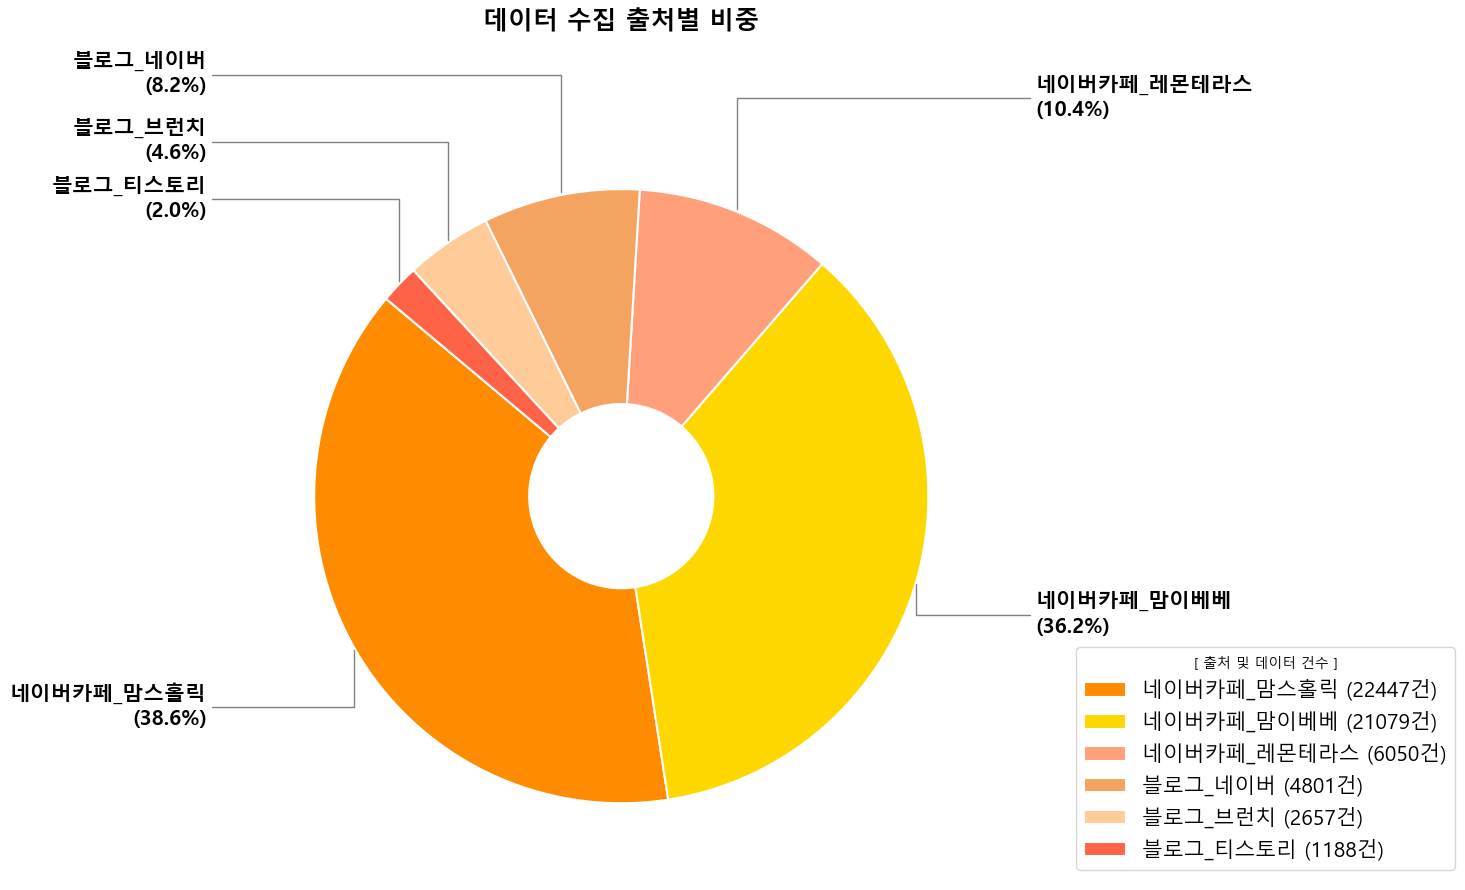

In [129]:
import matplotlib.pyplot as plt
import numpy as np
import platform

# 1. 한글 폰트 및 마이너스 기호 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 준비
source_counts = final_cleaned_df['출처'].value_counts()
labels_raw = source_counts.index
values = source_counts.values

# 범례용 라벨 생성: 출처명 (00건) 형식
legend_labels = [f'{label} ({value}건)' for label, value in zip(labels_raw, values)]

# 3. 색상 설정 (구분이 명확한 따뜻한 계열 파스텔톤 조합)
colors = [
    '#FF8C00', # 다크 오렌지
    '#FFD700', # 골드
    '#FFA07A', # 라이트 새먼
    '#F4A460', # 샌디 브라운
    '#FFCC99', # 피치
    '#FF6347', # 토마토
    '#E9967A'  # 다크 새먼
]

# 4. 그래프 생성
fig, ax = plt.subplots(figsize=(14, 9), subplot_kw=dict(aspect="equal"))

# 파이차트 그리기
wedges, _ = ax.pie(values, 
                   startangle=140, 
                   colors=colors[:len(labels_raw)],
                   wedgeprops=dict(width=0.7, edgecolor='w', linewidth=1.5))

# 5. 꺾은 선(Callout lines) 및 외부 레이블 추가
kw = dict(arrowprops=dict(arrowstyle="-", color="gray", connectionstyle="angle,angleA=0,angleB=90"), 
          va="center", fontsize=15, weight='bold')

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    
    # 퍼센트 표시 텍스트
    percentage = f'{values[i]/sum(values)*100:.1f}%'
    label_text = f"{labels_raw[i]}\n({percentage})"
    
    # 주석 달기 (꺾은 선 연결)
    ax.annotate(label_text, 
                xy=(x, y), 
                xytext=(1.35*np.sign(x), 1.4*y),
                horizontalalignment=horizontalalignment, 
                **kw)

# 6. 범례 설정 (출처명과 건수 포함, 오른쪽 아래 배치)
ax.legend(wedges, legend_labels,
          title="[ 출처 및 데이터 건수 ]",
          loc="lower right",
          bbox_to_anchor=(1.6, 0),
          fontsize=15)

ax.set_title("데이터 수집 출처별 비중", fontsize=18, pad=60, weight='bold')

plt.tight_layout()
plt.show()

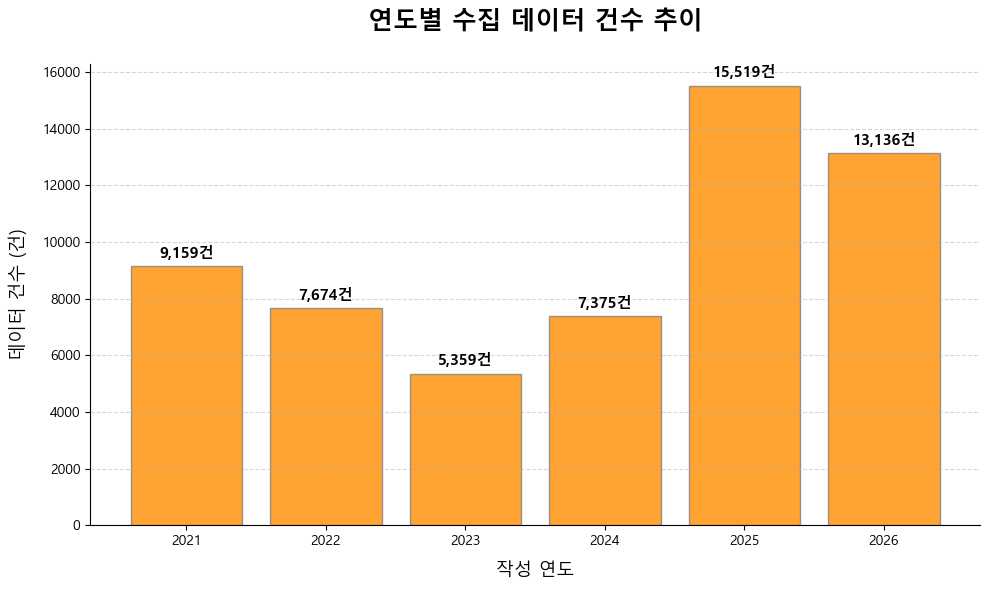

In [130]:
import matplotlib.pyplot as plt
import pandas as pd
import platform

# 1. 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumBarunGothic')

# 2. 데이터 그룹화 로직 적용
# '작성연도'를 숫자로 변환하여 2020 이하는 '2021 이전'으로 묶기
final_cleaned_df['작성연도_int'] = pd.to_numeric(final_cleaned_df['작성연도'], errors='coerce')
final_cleaned_df['작성연도_표시'] = final_cleaned_df['작성연도_int'].apply(
    lambda x: '2021 이전' if x <= 2020 else str(int(x))
)

# 3. 데이터 준비 및 정렬
year_counts = final_cleaned_df['작성연도_표시'].value_counts()

# 정렬 순서 정의: '2021 이전'을 맨 앞으로, 그 뒤로 연도순 정렬
years_only = sorted([c for c in year_counts.index if c != '2021 이전'])
final_order = (['2021 이전'] if '2021 이전' in year_counts.index else []) + years_only
year_counts = year_counts.reindex(final_order)

# 4. 그래프 생성
plt.figure(figsize=(10, 6))
colors = ['#FF8C00', '#FF8C00', '#FF8C00', '#FF8C00', '#FF8C00', '#FF8C00', '#FF8C00']

bars = plt.bar(year_counts.index, year_counts.values, 
               color=colors[:len(year_counts)], 
               edgecolor='gray', 
               linewidth=1,
               alpha=0.8)

# 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + (max(year_counts.values) * 0.01),
             f'{int(height):,}건', 
             ha='center', va='bottom', fontsize=11, weight='bold')

# 그래프 꾸미기
plt.title('연도별 수집 데이터 건수 추이', fontsize=18, pad=25, weight='bold')
plt.xlabel('작성 연도', fontsize=13, labelpad=10)
plt.ylabel('데이터 건수 (건)', fontsize=13, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [131]:
# 작성월
final_cleaned_df['작성월'] = final_cleaned_df['작성일'].str[5:7]
final_cleaned_df.head()

,출처,키워드,제목,내용,작성일,링크,작성연도,작성연도_int,작성연도_표시,작성월
0,네이버카페_레몬테라스,육아일기,돌아기 전집 뭐가 좋나요,이제 돌 지나서 돌 전집 사주려고 하는데요 프뢰벨 영아다중이랑 말하기 이렇게만 있거...,2024-12-31,https://cafe.naver.com/f-e/cafes/10298136/arti...,2024,2024,2024,12
1,블로그_네이버,임신,하지불안증후군 증상 치료 원인 완치가능성,하지불안증후군 다리에서 불쾌한 감각을 느끼고 이를 해소하기 위하여 움직이고 싶은 강...,2024-12-31,https://blog.naver.com/rkfkadk04/223710185729,2024,2024,2024,12
2,네이버카페_맘이베베,육아질문방,주차 튼살크림 추천해주세요,튼살크림이 종류가 엄청 많더라구요 그래서 알아보고 있는데 종류가 너무 다양해서 고민...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,2024,2024,2024,12
3,블로그_네이버,육아,셀프 산후조리 시작 완모 산후도우미 불러야할까,셀프 산후조리 시작 완모 산후도우미 불러야할까 오늘 입원 마지막 날 우리는 셋이 되...,2024-12-31,https://blog.naver.com/today_h/223711009087,2024,2024,2024,12
4,네이버카페_맘이베베,육아질문방,입덧약 처방 받아야 할지 좀 참아볼지 고민입니다,둘째는 입덧이 다르네요 음식을 먹고난 직후가 제일 심하고 냄새에 엄청 예민해지고 체...,2024-12-31,https://cafe.naver.com/f-e/cafes/29434212/arti...,2024,2024,2024,12


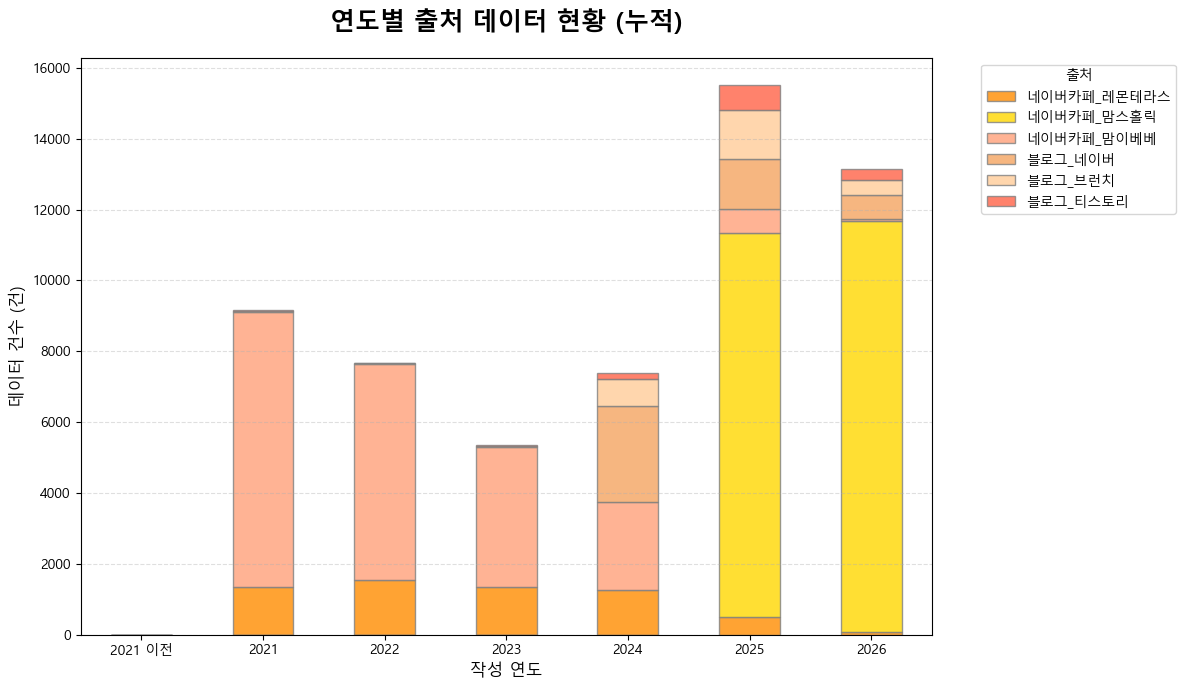

In [132]:
import matplotlib.pyplot as plt
import pandas as pd
import platform

# 1. 한글 폰트 및 마이너스 기호 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 재구조화 (Pivot Table)
# 행은 '작성연도_표시', 열은 '출처'로 하여 데이터 건수를 집계합니다.
pivot_df = final_cleaned_df.groupby(['작성연도_표시', '출처']).size().unstack(fill_value=0)

# 이전 단계에서 설정한 연도 순서대로 정렬 (2021 이전 -> 2022 -> ...)
years_order = ['2021 이전'] + sorted([c for c in pivot_df.index if c != '2021 이전'])
pivot_df = pivot_df.reindex(years_order)

# 3. 누적 막대 그래프 시각화
# 파이차트에서 사용했던 따뜻한 주황색 계열 파스텔 톤 적용
colors = ['#FF8C00', '#FFD700', '#FFA07A', '#F4A460', '#FFCC99', '#FF6347', '#E9967A']

ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 7), 
                   color=colors[:len(pivot_df.columns)], alpha=0.8, edgecolor='gray')

# 4. 그래프 디테일 설정
plt.title('연도별 출처 데이터 현황 (누적)', fontsize=18, pad=20, weight='bold')
plt.xlabel('작성 연도', fontsize=12)
plt.ylabel('데이터 건수 (건)', fontsize=12)
plt.xticks(rotation=0) # X축 라벨 가로로 표시
plt.legend(title='출처', bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 그래프 밖으로 이동
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 각 막대 위에 전체 합계 표시
for i, (name, row) in enumerate(pivot_df.iterrows()):
    total = row.sum()
    plt.text(i, total + (pivot_df.values.max() * 0.02), f'{int(total):,}건', 
             ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

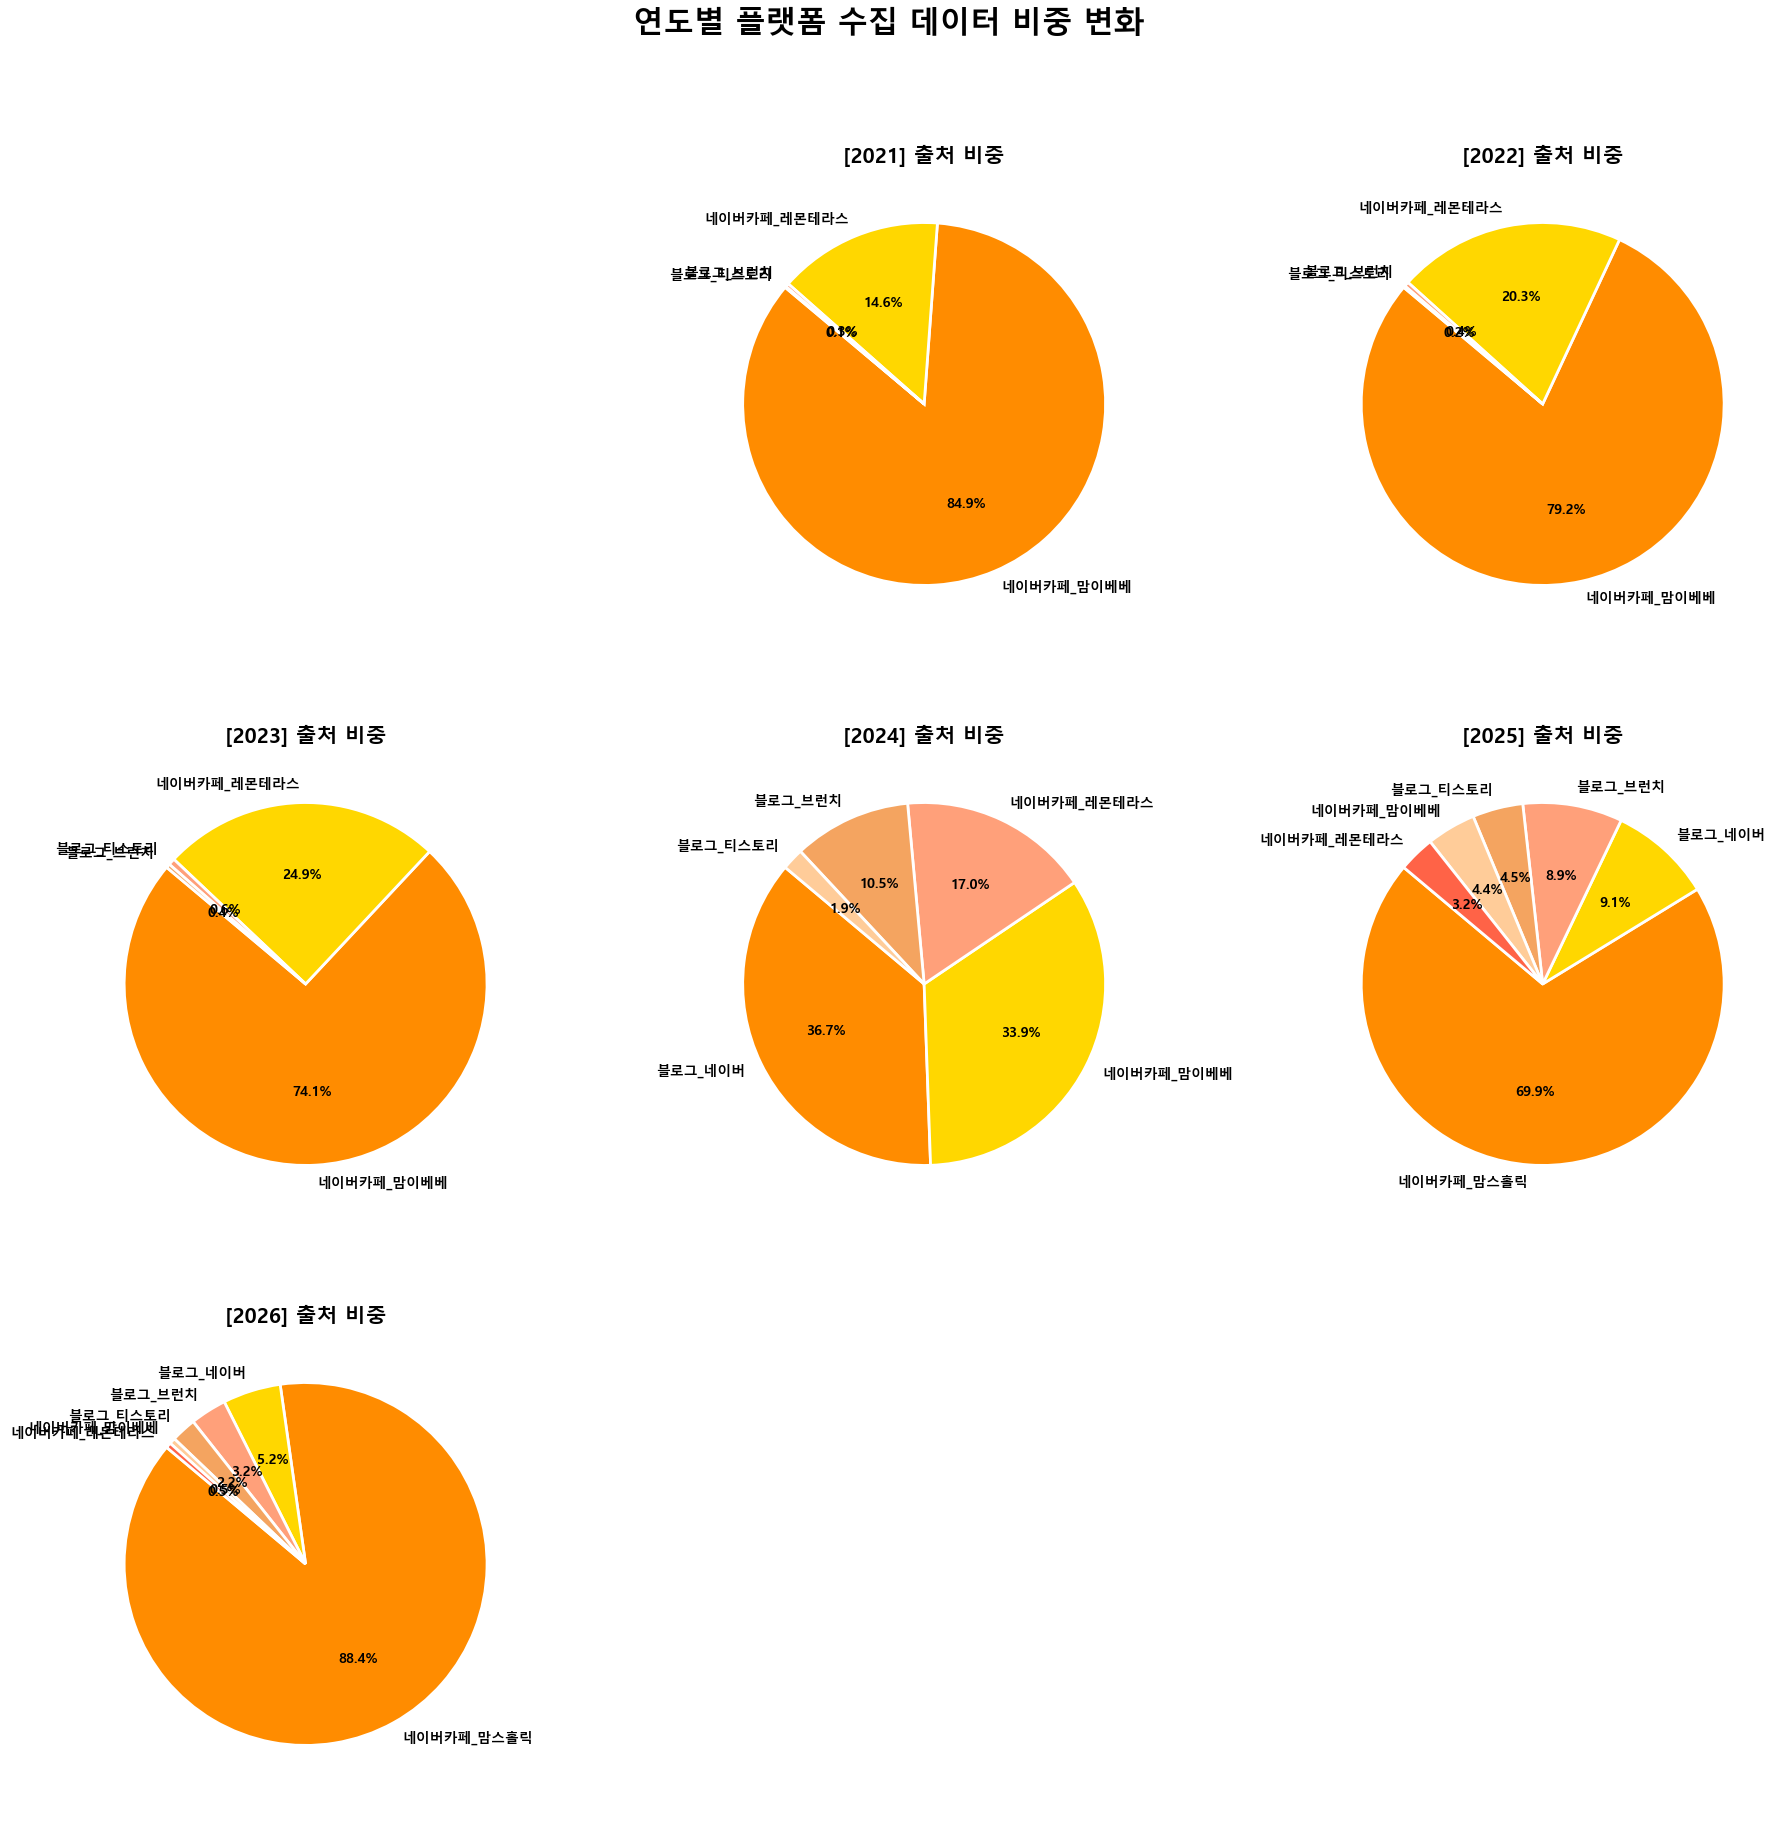

In [133]:
import matplotlib.pyplot as plt
import platform
import math

# 1. 한글 폰트 및 마이너스 기호 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 준비 및 연도 순서 설정
# 이전 단계에서 생성한 '작성연도_표시' 컬럼 활용
years_order = ['2021 이전'] + sorted([c for c in final_cleaned_df['작성연도_표시'].unique() if c != '2021 이전'])
n_years = len(years_order)

# 3. 그래프 레이아웃 설정 (한 줄에 최대 3개씩 배치)
cols = 3
rows = math.ceil(n_years / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
axes = axes.flatten() # 2차원 배열을 1차원으로 변환하여 반복문 쓰기 편하게 함

# 색상 설정 (이전과 동일한 주황색 계열 파스텔 톤)
colors = ['#FF8C00', '#FFD700', '#FFA07A', '#F4A460', '#FFCC99', '#FF6347', '#E9967A']

# 4. 연도별로 파이차트 그리기
for i, year in enumerate(years_order):
    # 해당 연도 데이터만 필터링
    year_data = final_cleaned_df[final_cleaned_df['작성연도_표시'] == year]['출처'].value_counts()
    
    if not year_data.empty:
        axes[i].pie(year_data, 
                    labels=year_data.index, 
                    autopct='%1.1f%%', 
                    startangle=140, 
                    colors=colors[:len(year_data)],
                    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
                    textprops={'fontsize': 10, 'weight': 'bold'})
        
        axes[i].set_title(f'[{year}] 출처 비중', fontsize=15, pad=10, weight='bold')
    else:
        axes[i].axis('off') # 데이터가 없는 칸은 숨김

# 5. 남는 서브플롯 숨기기
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('연도별 플랫폼 수집 데이터 비중 변화', fontsize=22, y=1.02, weight='bold')
plt.tight_layout()
plt.show()

In [134]:
# 1. 필터링할 출처 리스트 설정
target_cafes = ['네이버카페_맘스홀릭', '네이버카페_맘이베베', '네이버카페_레몬테라스']

# 2. 복합 조건 필터링
# 조건 1: 출처가 target_cafes 리스트에 포함됨
# 조건 2: 내용 컬럼의 문자열 길이가 500 이상
df_cafe_long = final_cleaned_df[
    (final_cleaned_df['출처'].isin(target_cafes)) & 
    (final_cleaned_df['내용'].str.len() >= 300)
]

# 3. 결과 확인
print(f"필터링 전 전체 데이터: {len(final_cleaned_df):,}건")
print(f"조건에 맞는 카페 데이터 (500자 이상): {len(df_cafe_long):,}건")

# 4. 인덱스 재정렬
df_cafe_long = df_cafe_long.reset_index(drop=True)

# 5. 상위 데이터 확인
df_cafe_long.head()

필터링 전 전체 데이터: 58,222건
조건에 맞는 카페 데이터 (500자 이상): 5,394건


,출처,키워드,제목,내용,작성일,링크,작성연도,작성연도_int,작성연도_표시,작성월
0,네이버카페_맘이베베,육아질문방,역아라 급히 제왕날짜 잡았는데 준비물좀 도와주세요,첫째 둘째 자분으로 잘 낳았는데 셋째는 갑분 역아라 제왕해야한다 해서 하늘이 노랗고...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,2024,2024,2024,12
1,네이버카페_맘이베베,육아질문방,인기없는 원장님은 이유가 있네요,간밤에 복통와 출혈로 글썼던 경산모입니다 제가 딱 년전 작년 월에 미즈 에서 다발성...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,2024,2024,2024,12
2,네이버카페_맘이베베,육아질문방,아기집 보고 왔는데 갑자기 복통과 출혈이,나이 만 세의 경산모입니다 자연임신 시도중이고 월에 주 들어서면서 화유 됐어요 이번...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,2024,2024,2024,12
3,네이버카페_맘이베베,육아질문방,법인 대표자 아내는 육아휴직 급여 못받나요,저는 남편이랑 년을 연애하고 결혼했어요 남편이 연애 년차쯤 사업을 시작해서 같이 회...,2024-12-30,https://cafe.naver.com/f-e/cafes/29434212/arti...,2024,2024,2024,12
4,네이버카페_맘이베베,육아질문방,개월 아기 짜증 저만 이런가요,개월 아기 일 를 키우고 있는데요 정말 너무너무너무너무 너 무 짜증이 늘고 고집이 ...,2024-12-28,https://cafe.naver.com/f-e/cafes/29434212/arti...,2024,2024,2024,12
